<a href="https://colab.research.google.com/github/kyuho11488/kyuho11488/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_13%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C_2021148025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np

data = np.array([
    [0, 1, 1, 0, 0],  # 1
    [0, 1, 1, 1, 0],  # 2
    [2, 1, 1, 0, 1],  # 3
    [1, 0, 1, 0, 1],  # 4
    [1, 0, 0, 0, 1],  # 5
    [1, 0, 0, 1, 0],  # 6
    [2, 0, 0, 1, 1],  # 7
    [0, 0, 0, 0, 1],  # 8
    [0, 0, 0, 1, 1],  # 9
    [1, 1, 0, 0, 1],  # 10
    [0, 0, 1, 0, 1],  # 11
    [2, 1, 0, 0, 1],  # 12
    [2, 1, 0, 1, 1],  # 13
    [1, 1, 1, 0, 0],  # 14
])

In [20]:
# 1-1 문제

X = data[:, 0:4]
y = data[:, 4].astype(int)

def entropy(y):
  # y의 고유값과 각각의 빈도수 계산하기
  values, counts = np.unique(y, return_counts=True)
  p = counts / counts.sum()  # pk
  # 엔트로피 계산하기
  return -np.sum(p * np.log2(p))

# 전체 데이터의 엔트로피 계산하기
total_entropy = entropy(y)
print(f"전체 데이터 엔트로피: {total_entropy:.4f}")

#  피처별(예보, 온도, 습도, 바람) 정보 이득(Information Gain) 계산하기
feature_names = ['예보', '온도', '습도', '바람']

for feature_idx in range(X.shape[1]):
    feature_values = np.unique(X[:, feature_idx])
    feature_entropy = 0
    for value in feature_values:
        # 해당 값에 해당하는 데이터 인덱스
        subset_y = y[X[:, feature_idx] == value]
        weight = len(subset_y) / len(y)
        subset_entropy = entropy(subset_y)
        feature_entropy += weight * subset_entropy
    info_gain = total_entropy - feature_entropy
    print(f" {feature_names[feature_idx]}의 정보 이득: {info_gain:.4f}")

전체 데이터 엔트로피: 0.8631
 예보의 정보 이득: 0.1696
 온도의 정보 이득: 0.0747
 습도의 정보 이득: 0.1239
 바람의 정보 이득: 0.0251


/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11

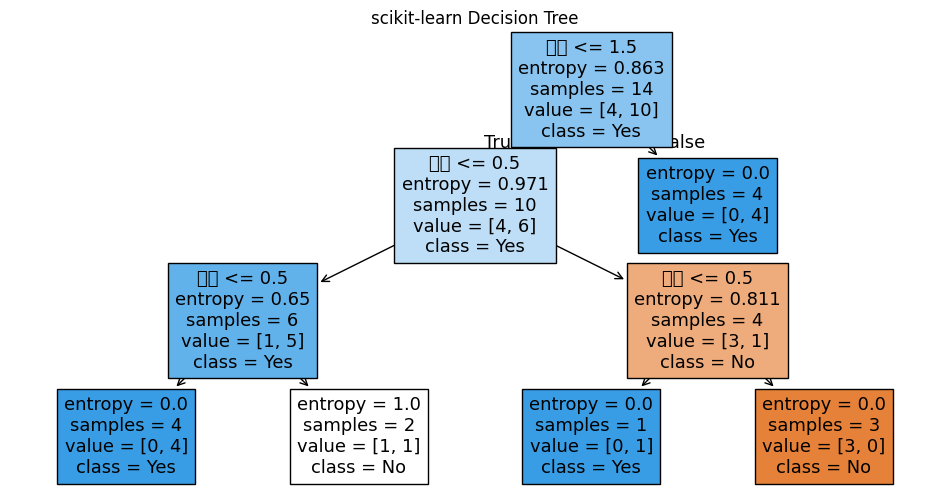

In [21]:
# 1-2 : 전체를 scikit learn 함수로 실행해서 plotting하기

import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 주어진 데이터
data = np.array([
    [0, 1, 1, 0, 0],  # 1
    [0, 1, 1, 1, 0],  # 2
    [2, 1, 1, 0, 1],  # 3
    [1, 0, 1, 0, 1],  # 4
    [1, 0, 0, 0, 1],  # 5
    [1, 0, 0, 1, 0],  # 6
    [2, 0, 0, 1, 1],  # 7
    [0, 0, 0, 0, 1],  # 8
    [0, 0, 0, 1, 1],  # 9
    [1, 1, 0, 0, 1],  # 10
    [0, 0, 1, 0, 1],  # 11
    [2, 1, 0, 0, 1],  # 12
    [2, 1, 0, 1, 1],  # 13
    [1, 1, 1, 0, 0],  # 14
])

X = data[:, :4]
y = data[:, 4]

# 이름 설정하기
feature_names = ['예보', '온도', '습도', '바람']
class_names = ['No', 'Yes']

# 모델 정의 및 학습하기
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, random_state = 0)
clf.fit(X, y)

# 트리 시각화하기
plt.figure(figsize = (12, 6))
plot_tree(clf, feature_names = feature_names, class_names = class_names, filled = True)
plt.title('scikit-learn Decision Tree')
plt.show()

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

In [24]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/drug200.csv')

In [25]:
print(df)

     Age Sex      BP Cholesterol  Na_to_K   Drug
0     23   F    HIGH        HIGH   25.355  drugY
1     47   M     LOW        HIGH   13.093  drugC
2     47   M     LOW        HIGH   10.114  drugC
3     28   F  NORMAL        HIGH    7.798  drugX
4     61   F     LOW        HIGH   18.043  drugY
..   ...  ..     ...         ...      ...    ...
195   56   F     LOW        HIGH   11.567  drugC
196   16   M     LOW        HIGH   12.006  drugC
197   52   M  NORMAL        HIGH    9.894  drugX
198   23   M  NORMAL      NORMAL   14.020  drugX
199   40   F     LOW      NORMAL   11.349  drugX

[200 rows x 6 columns]


In [26]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


<ipython-input-27-b6355ace96c7>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'F' : 2, 'M' : 1})
<ipython-input-27-b6355ace96c7>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BP'] = df['BP'].replace({'HIGH' : 2, 'LOW' : 1, 'NORMAL' : 0})
<ipython-input-27-b6355ace96c7>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, s

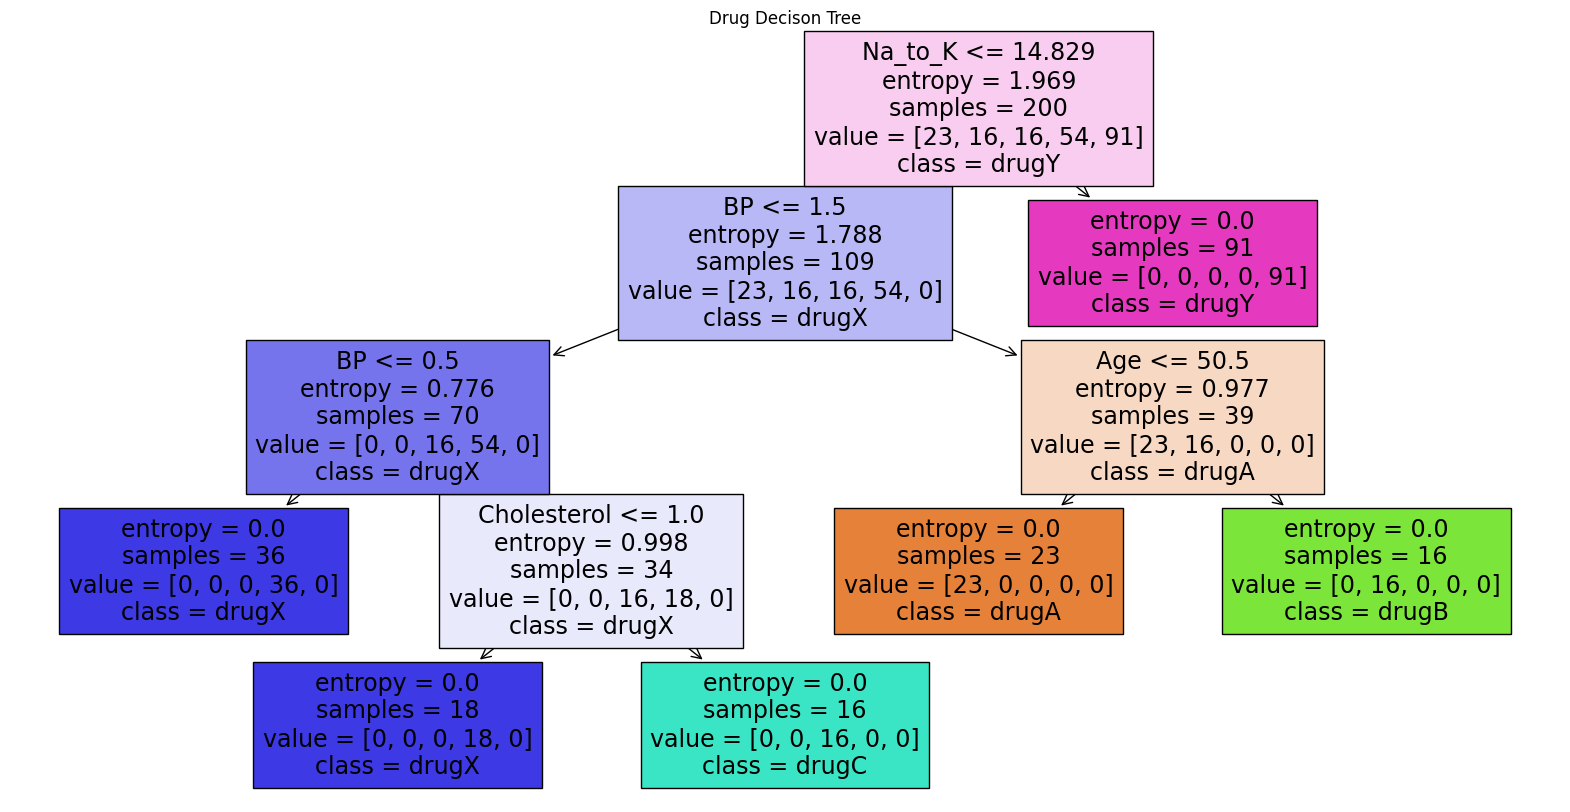

In [27]:
# 2 : drug200 데이터로 Decision Tree 모델 생성 및 시각화하기

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/drug200.csv')

# 전처리하기
df['Sex'] = df['Sex'].replace({'F' : 2, 'M' : 1})
df['BP'] = df['BP'].replace({'HIGH' : 2, 'LOW' : 1, 'NORMAL' : 0})
df['Cholesterol'] = df['Cholesterol'].replace({'HIGH' : 2, 'LOW' : 1, 'NORMAL' : 0})
df['Drug'] = df['Drug'].replace({'drugA' : 1, 'drugB' : 2, 'drugC' : 3, 'drugX' : 4, 'drugY' : 5})
df.head()

# 특성과 타깃 분리하기
X = df.drop('Drug', axis = 1)
y = df['Drug']

# 결정트리 분류기 학습하기
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 4, random_state = 0)
clf.fit(X, y)

# 트리 시각화하기
plt.figure(figsize = (20, 10))
plot_tree(clf, feature_names = X.columns, class_names = ['drugA', 'drugB', 'drugC', 'drugX', 'drugY'], filled = True)
plt.title('Drug Decison Tree')
plt.show()